In [4]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
#dataset loading
df = pd.read_csv("solarpowergeneration.csv")
print(df.head())

   temperature_2_m_above_gnd  relative_humidity_2_m_above_gnd  \
0                       2.17                               31   
1                       2.31                               27   
2                       3.65                               33   
3                       5.82                               30   
4                       7.73                               27   

   mean_sea_level_pressure_MSL  total_precipitation_sfc  snowfall_amount_sfc  \
0                       1035.0                      0.0                  0.0   
1                       1035.1                      0.0                  0.0   
2                       1035.4                      0.0                  0.0   
3                       1035.4                      0.0                  0.0   
4                       1034.4                      0.0                  0.0   

   total_cloud_cover_sfc  high_cloud_cover_high_cld_lay  \
0                    0.0                              0   
1         

In [6]:
#data cleaning
print(df.isnull().sum())

temperature_2_m_above_gnd            0
relative_humidity_2_m_above_gnd      0
mean_sea_level_pressure_MSL          0
total_precipitation_sfc              0
snowfall_amount_sfc                  0
total_cloud_cover_sfc                0
high_cloud_cover_high_cld_lay        0
medium_cloud_cover_mid_cld_lay       0
low_cloud_cover_low_cld_lay          0
shortwave_radiation_backwards_sfc    0
wind_speed_10_m_above_gnd            0
wind_direction_10_m_above_gnd        0
wind_speed_80_m_above_gnd            0
wind_direction_80_m_above_gnd        0
wind_speed_900_mb                    0
wind_direction_900_mb                0
wind_gust_10_m_above_gnd             0
angle_of_incidence                   0
zenith                               0
azimuth                              0
generated_power_kw                   0
dtype: int64


In [7]:
X = df[['temperature_2_m_above_gnd', 'relative_humidity_2_m_above_gnd', 'angle_of_incidence', 'wind_speed_10_m_above_gnd']]
Y = df[['generated_power_kw']]

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.fit_transform(X_test)

In [10]:
model = LinearRegression()
model.fit(X_poly_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
Y_pred = model.predict(X_poly_test)

In [12]:
#model evaluation
mse = mean_squared_error(Y_test, Y_pred)
print(f"Mean squared error: {mse}")
r2 = r2_score(Y_test, Y_pred)
print(f"R-Squared: {r2}")

Mean squared error: 393879.7405263695
R-Squared: 0.5688063886012


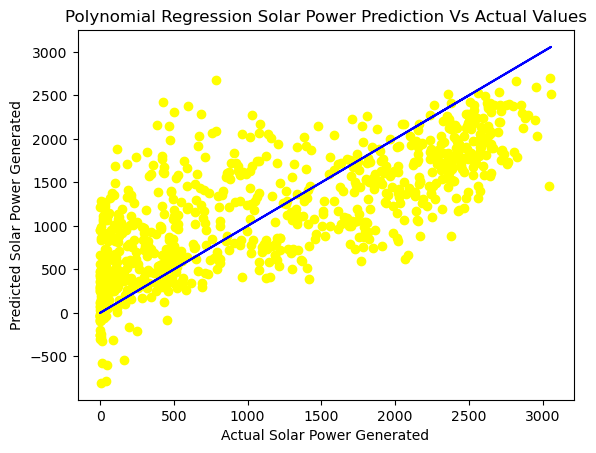

In [13]:
#visualization
plt.scatter(Y_test, Y_pred, color="yellow")
plt.plot(Y_test, Y_test, color="blue")
plt.xlabel("Actual Solar Power Generated")
plt.ylabel("Predicted Solar Power Generated")
plt.title("Polynomial Regression Solar Power Prediction Vs Actual Values")
plt.show()